<a href="https://colab.research.google.com/github/acgibbs12/cosc-650-applied-llm-systems/blob/4-temp-and-top-p-sampling-behavior/week-02/week2_inference_sampling_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 (starter): Inference and Sampling

Runs as-is on a small local model so you can see each stage; cells marked **TODO (you)** are where you do the work. No GPU, no API key. Dependencies: `transformers`, `torch` (CPU), `numpy`, `matplotlib`.

Parts: trace the forward pass, build the sampling explorer, evaluate three settings, find one failure, submit.

In [1]:
#!pip install transformers torch numpy matplotlib
import os, pathlib
os.environ['HF_HOME'] = str((pathlib.Path('.') / '.hf_cache').resolve())
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
torch.manual_seed(0)
name = 'distilgpt2'
tok = AutoTokenizer.from_pretrained(name)
model = AutoModelForCausalLM.from_pretrained(name, attn_implementation='eager')
model.eval()
cfg = model.config
print(f'{name}: {cfg.n_layer} layers, {cfg.n_head} heads, embed dim {cfg.n_embd}, vocab {cfg.vocab_size}')

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

distilgpt2: 6 layers, 12 heads, embed dim 768, vocab 50257


## Part 1: Trace the forward pass
**TODO (you):** change the prompt to your own. Read off the real numbers at each stage.

In [2]:
prompt = 'Explain to me in no more than 2 short paragraphs how a V8 engine works.'
enc = tok(prompt, return_tensors='pt')
ids = enc['input_ids'][0]
print('token IDs:', ids.tolist())
for i, t in enumerate(ids.tolist()):
    print(f'  pos {i}: id {t:6d} -> {tok.decode([t])!r}')

emb = model.transformer.wte(ids)
print('\nembedded prompt shape (seq_len, dim):', tuple(emb.shape))

with torch.no_grad():
    out = model(**enc, output_attentions=True)
att = out.attentions[0][0, 0, -1]   # layer 0, head 0, last token attends to...
print('last-token attention (layer 0, head 0), sums to', round(att.sum().item(), 4))
for j in range(ids.shape[0]):
    print(f'  {tok.decode([ids[j]])!r:12s} {att[j].item():.3f}')

with torch.no_grad():
    logits = model(**enc).logits
print('\nlogits shape (batch, seq, vocab):', tuple(logits.shape))
probs = torch.softmax(logits[0, -1], dim=-1)
top = torch.topk(probs, 10)
print('top 10 next tokens:')
for p, idx in zip(top.values.tolist(), top.indices.tolist()):
    print(f'  {tok.decode([idx])!r:14s} {p:.4f}')
next_logits = logits[0, -1]

token IDs: [18438, 391, 284, 502, 287, 645, 517, 621, 362, 1790, 23549, 703, 257, 569, 23, 3113, 2499, 13]
  pos 0: id  18438 -> 'Expl'
  pos 1: id    391 -> 'ain'
  pos 2: id    284 -> ' to'
  pos 3: id    502 -> ' me'
  pos 4: id    287 -> ' in'
  pos 5: id    645 -> ' no'
  pos 6: id    517 -> ' more'
  pos 7: id    621 -> ' than'
  pos 8: id    362 -> ' 2'
  pos 9: id   1790 -> ' short'
  pos 10: id  23549 -> ' paragraphs'
  pos 11: id    703 -> ' how'
  pos 12: id    257 -> ' a'
  pos 13: id    569 -> ' V'
  pos 14: id     23 -> '8'
  pos 15: id   3113 -> ' engine'
  pos 16: id   2499 -> ' works'
  pos 17: id     13 -> '.'

embedded prompt shape (seq_len, dim): (18, 768)
last-token attention (layer 0, head 0), sums to 1.0
  'Expl'       0.245
  'ain'        0.051
  ' to'        0.013
  ' me'        0.080
  ' in'        0.013
  ' no'        0.036
  ' more'      0.023
  ' than'      0.023
  ' 2'         0.016
  ' short'     0.033
  ' paragraphs' 0.159
  ' how'       0.064
  ' a'    

## Part 2: Build the sampling explorer
Temperature, top-k, and top-p over the model's real next-token distribution.

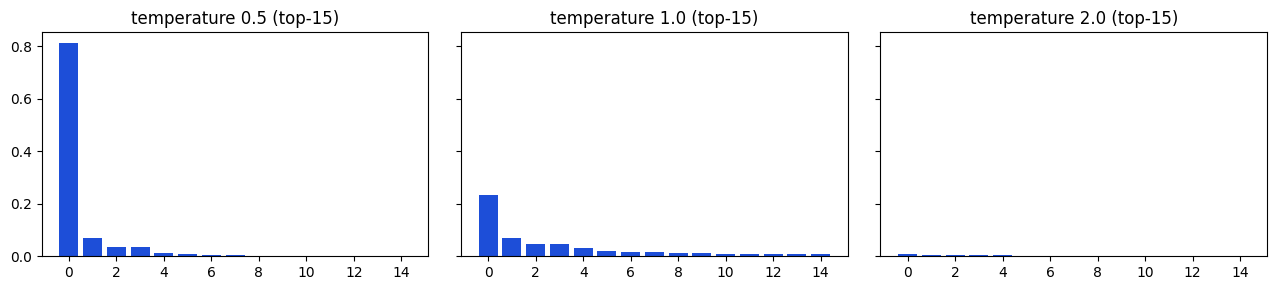

top token prob: temp 0.5 = 0.812, temp 1.0 = 0.232, temp 2.0 = 0.009


In [3]:
import numpy as np, matplotlib.pyplot as plt
z = next_logits.detach().numpy()

def softmax(x):
    x = x - x.max(); e = np.exp(x); return e / e.sum()
def temperature(z, t):
    return softmax(z / t)
def top_k(p, k):
    out = np.zeros_like(p); idx = np.argsort(p)[::-1][:k]; out[idx] = p[idx]; return out / out.sum()
def top_p(p, thresh):
    order = np.argsort(p)[::-1]; cdf = np.cumsum(p[order]); cut = np.searchsorted(cdf, thresh) + 1
    out = np.zeros_like(p); out[order[:cut]] = p[order[:cut]]; return out / out.sum(), cut

base = softmax(z)
fig, axes = plt.subplots(1, 3, figsize=(13, 3), sharey=True)
for ax, t in zip(axes, [0.5, 1.0, 2.0]):
    pt = temperature(z, t)
    ax.bar(range(15), np.sort(pt)[::-1][:15], color='#1d4ed8')
    ax.set_title(f'temperature {t} (top-15)')
plt.tight_layout(); plt.show()
print('top token prob: temp 0.5 = %.3f, temp 1.0 = %.3f, temp 2.0 = %.3f' % (
    temperature(z,0.5).max(), temperature(z,1.0).max(), temperature(z,2.0).max()))

## Part 3: Evaluate three settings with real figures
Predict first, then read the entropy, the maximum probability, and how many tokens survive.

For temperature 1e-6, I predict that the entropy will be very low and that the maximum probability will be close to 1 because the distribution should be heavily concentrated on the most likely token.

For Temp 0.7, I predict that entropy will increase/maximum probability will decrease since the the probability distribution should spread out.

For temp 1.3, I predict this will have the highest entropy and lowest maximum probability. However, I believe that top-p = 0.9 should restrict the final candidate set to the smallest group of tokens whose cumulative probability reaches 90%.

In [4]:
def entropy(p):
    p = p[p > 0]; return float(-(p * np.log(p)).sum())
for t, tp in [(1e-6, 1.0), (0.7, 1.0), (1.3, 0.9)]:
    p = temperature(z, t)
    _, kept = top_p(p, tp)
    print(f'temp {t:<6} top-p {tp}: entropy {entropy(p):.3f}, max prob {p.max():.3f}, nucleus keeps {kept} tokens')

temp 1e-06  top-p 1.0: entropy -0.000, max prob 1.000, nucleus keeps 1 tokens
temp 0.7    top-p 1.0: entropy 2.172, max prob 0.565, nucleus keeps 50258 tokens
temp 1.3    top-p 0.9: entropy 7.429, max prob 0.076, nucleus keeps 6725 tokens


## Part 4: Find one failure and explain it (required)
**TODO (you):** show one surprising case and explain the cause and mitigation. A starter is below.

In [5]:
# starter failure: near-zero temperature collapses to a single token
p0 = temperature(z, 1e-6)
print('temp -> 0: top token prob =', round(p0.max(), 6), '(greedy collapse)')
# TODO (you): find your own surprising case (e.g. top-p = 1.0 keeps the whole vocab) and explain it.

temp -> 0: top token prob = 1.0 (greedy collapse)


In [6]:
p = temperature(z, 1.3)
_, kept = top_p(p, 0.9)

print('Max probability:', p.max())


Max probability: 0.076042086


For temperature 1.3, I predicted that the probability distribution will be more spread out than at lower temperatures. I am surprised to see how low max probability is even though temperature is only at 1.3. I figured that it would have the lowest probability, but I expected it to be much higher than 0.07.

## Part 5: Submit
Run top to bottom on your prompt, then open a pull request with a result summary, the notebook, and a linked research-note issue. Rubric: trace (30), sampling explorer (25), three settings evaluated (20), failure case (15), PR hygiene (10).